# Playing with `piepy.stats.aggregate`

The aggregator turns a trial table into a **tidy** per-condition estimate frame — one row
per `(group × metric)` with `value`, `ci_low`, `ci_high`, `n`. It is experiment-agnostic
(you name the grouping columns and the metrics) and the output is plotting-ready.

This notebook runs on **synthetic data** so it works anywhere; the final cell shows an
optional real-session example.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from piepy.stats import aggregate, group_arrays, Rate, Mean, Median, Count

pl.Config(set_tbl_rows=20)

## A synthetic detection dataset

3 animals × a range of signed contrasts. Hit rate rises with |contrast| (detection-style),
reaction times are gamma-distributed and a little slower on opto trials. Tweak anything here
and re-run the cells below.

In [2]:
rng = np.random.default_rng(0)
contrasts = [-1.0, -0.5, -0.25, -0.125, 0.0, 0.125, 0.25, 0.5, 1.0]
animals = ["M1", "M2", "M3"]

rows = []
for animal in animals:
    slope = rng.uniform(7, 12)
    lapse = rng.uniform(0.02, 0.08)
    for c in contrasts:
        n = int(rng.integers(25, 45))
        p_hit = lapse + (1 - 2 * lapse) / (1 + np.exp(-slope * (abs(c) - 0.15)))
        for _ in range(n):
            hit = rng.random() < p_hit
            opto = rng.random() < 0.3
            rt = 150 + rng.gamma(2.0, 120) + (80 if opto else 0)
            rows.append(
                dict(
                    animalid=animal,
                    signed_contrast=c,
                    is_hit=int(hit),
                    outcome="hit" if hit else "miss",
                    opto=opto,
                    reaction_time=float(rt),
                )
            )

df = pl.DataFrame(rows)
print(df.shape)
df.head()

(911, 6)


animalid,signed_contrast,is_hit,outcome,opto,reaction_time
str,f64,i64,str,bool,f64
"""M1""",-1.0,1,"""hit""",false,411.410869
"""M1""",-1.0,1,"""hit""",false,211.037533
"""M1""",-1.0,1,"""hit""",false,317.983676
"""M1""",-1.0,1,"""hit""",false,304.891881
"""M1""",-1.0,1,"""hit""",true,725.164403


## 1. Hit rate per condition (shorthand)

`rate="is_hit"` → proportion with a **Wilson** CI, which stays inside `[0, 1]` even at
0% / 100%. The result is tidy: `signed_contrast | metric | value | ci_low | ci_high | n`.

In [3]:
psych = aggregate(df, group="signed_contrast", rate="is_hit").sort("signed_contrast")
psych

signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
-1.0,"""rate[is_hit]""",0.959596,0.90068,0.984177,99
-0.5,"""rate[is_hit]""",0.9375,0.876586,0.969398,112
-0.25,"""rate[is_hit]""",0.715909,0.614204,0.799552,88
-0.125,"""rate[is_hit]""",0.412281,0.326219,0.504061,114
0.0,"""rate[is_hit]""",0.220183,0.152664,0.306755,109
0.125,"""rate[is_hit]""",0.59,0.492014,0.681327,100
0.25,"""rate[is_hit]""",0.728261,0.629581,0.808642,92
0.5,"""rate[is_hit]""",0.978022,0.923368,0.993952,91
1.0,"""rate[is_hit]""",0.971698,0.920074,0.990329,106


## 2. The output is plotting-ready

`value` plus the `ci_low`/`ci_high` columns drop straight into an errorbar. In the real
pipeline behaviz draws this — here we use matplotlib so the notebook is self-contained.

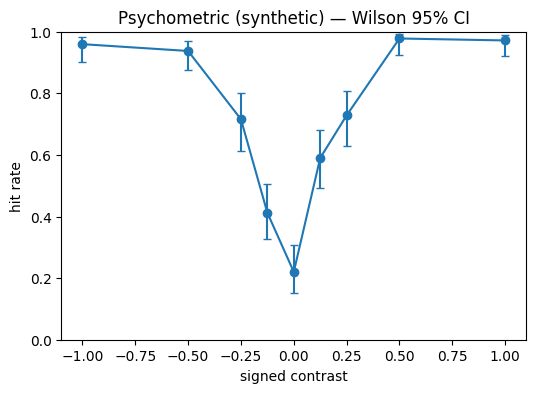

In [4]:
x = psych["signed_contrast"].to_numpy()
y = psych["value"].to_numpy()
yerr = np.vstack([y - psych["ci_low"].to_numpy(), psych["ci_high"].to_numpy() - y])

plt.figure(figsize=(6, 4))
plt.errorbar(x, y, yerr=yerr, marker="o", capsize=3)
plt.ylim(0, 1)
plt.xlabel("signed contrast")
plt.ylabel("hit rate")
plt.title("Psychometric (synthetic) — Wilson 95% CI")
plt.show()

## 3. Median reaction time per condition

`value="reaction_time", stat="median"` → median with the analytic **order-statistic** CI
(fast, deterministic, no bootstrap loop). Prefer bootstrap? use
`metrics=[Median("reaction_time", ci="bootstrap")]`.

In [5]:
aggregate(df, group="signed_contrast", value="reaction_time", stat="median").sort(
    "signed_contrast"
)

signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
-1.0,"""median[reaction_time]""",364.920716,336.327189,411.410869,99
-0.5,"""median[reaction_time]""",359.341872,329.44576,382.588512,112
-0.25,"""median[reaction_time]""",358.432397,322.87544,381.028369,88
-0.125,"""median[reaction_time]""",379.754542,333.848181,423.920703,114
0.0,"""median[reaction_time]""",378.35484,355.754157,408.708526,109
0.125,"""median[reaction_time]""",389.291443,355.430014,434.202083,100
0.25,"""median[reaction_time]""",395.514237,363.336432,433.381222,92
0.5,"""median[reaction_time]""",364.257642,320.088856,402.837538,91
1.0,"""median[reaction_time]""",408.984044,344.665149,468.566397,106


## 4. Several metrics in one pass

Pass a list of metric specs; the output stays tidy (one row per group × metric).

In [13]:
aggregate(
    df,
    group=["animalid","opto"],
    metrics=[Rate("is_hit"), Median("reaction_time"), Mean("reaction_time"), Count()],
).sort(["animalid","opto", "metric"])

animalid,opto,metric,value,ci_low,ci_high,n
str,bool,str,f64,f64,f64,i64
"""M1""",false,"""count""",189.0,null,null,189
"""M1""",false,"""mean[reaction_time]""",384.727178,362.083349,407.371007,189
"""M1""",false,"""median[reaction_time]""",358.378324,327.53467,385.442042,189
"""M1""",false,"""rate[is_hit]""",0.703704,0.635071,0.764221,189
"""M1""",true,"""count""",79.0,null,null,79
"""M1""",true,"""mean[reaction_time]""",458.723063,420.382066,497.064059,79
"""M1""",true,"""median[reaction_time]""",402.837538,379.015641,448.524227,79
"""M1""",true,"""rate[is_hit]""",0.632911,0.522769,0.730727,79
"""M2""",false,"""count""",200.0,null,null,200


## 5. Group by anything — e.g. animal × condition

Just add columns to `group`. Here: one psychometric per animal.

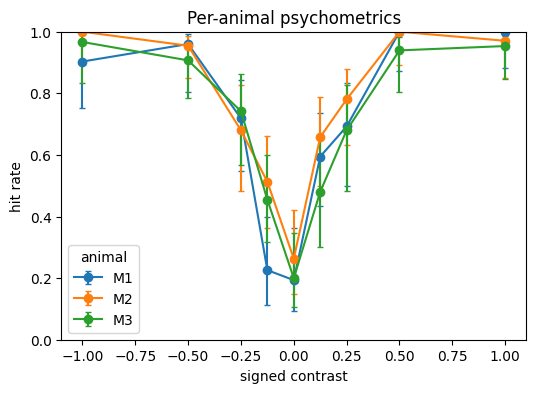

In [7]:
per = aggregate(df, group=["animalid", "signed_contrast"], rate="is_hit").sort(
    ["animalid", "signed_contrast"]
)

plt.figure(figsize=(6, 4))
for animal in per["animalid"].unique(maintain_order=True):
    sub = per.filter(pl.col("animalid") == animal)
    xx, yy = sub["signed_contrast"].to_numpy(), sub["value"].to_numpy()
    err = np.vstack([yy - sub["ci_low"].to_numpy(), sub["ci_high"].to_numpy() - yy])
    plt.errorbar(xx, yy, yerr=err, marker="o", capsize=2, label=animal)
plt.ylim(0, 1)
plt.xlabel("signed contrast")
plt.ylabel("hit rate")
plt.legend(title="animal")
plt.title("Per-animal psychometrics")
plt.show()

## 6. Rate from a categorical column

`Rate("outcome", success="hit")` works off a string column — same result as the 0/1 `is_hit`.

In [8]:
aggregate(df, group="signed_contrast", metrics=[Rate("outcome", success="hit")]).sort(
    "signed_contrast"
)

signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
-1.0,"""rate[outcome=hit]""",0.959596,0.90068,0.984177,99
-0.5,"""rate[outcome=hit]""",0.9375,0.876586,0.969398,112
-0.25,"""rate[outcome=hit]""",0.715909,0.614204,0.799552,88
-0.125,"""rate[outcome=hit]""",0.412281,0.326219,0.504061,114
0.0,"""rate[outcome=hit]""",0.220183,0.152664,0.306755,109
0.125,"""rate[outcome=hit]""",0.59,0.492014,0.681327,100
0.25,"""rate[outcome=hit]""",0.728261,0.629581,0.808642,92
0.5,"""rate[outcome=hit]""",0.978022,0.923368,0.993952,91
1.0,"""rate[outcome=hit]""",0.971698,0.920074,0.990329,106


## 7. Raw arrays for statistical tests

`group_arrays` hands you the per-group arrays to feed a test. (Chunk 2 will add
`piepy.stats.compare`; here we preview with scipy directly.)

In [10]:
from scipy.stats import mannwhitneyu

arrs = group_arrays(df, group="opto", value="reaction_time")
u, p = mannwhitneyu(arrs[True], arrs[False])
print(f"opto (n={arrs[True].size}) vs control (n={arrs[False].size}) reaction time")
print(f"Mann-Whitney U={u:.0f}, p={p:.3g}")

opto (n=299) vs control (n=612) reaction time
Mann-Whitney U=121813, p=4.29e-16


## 8. Robustness

Empty groups become `n=0` with `null` estimates (never a crash), null group **keys** are
kept as their own group, and a missing column raises a clear error.

In [11]:
demo = pl.DataFrame({"cond": ["a", "a", "b", None], "rt": [1.0, 2.0, None, 5.0]})
aggregate(demo, group="cond", value="rt", stat="median")  # b has no rt -> n=0; null key kept

cond,metric,value,ci_low,ci_high,n
str,str,f64,f64,f64,i64
null,"""median[rt]""",5.0,5.0,5.0,1
"""a""","""median[rt]""",1.5,1.0,2.0,2
"""b""","""median[rt]""",null,null,null,0


## (Optional) A real session

Needs lab data + `~/.piepy/config.json`. Analysis writes are redirected to a temp dir so
nothing is clobbered, and the cell skips cleanly if the session isn't available locally.

In [12]:
import tempfile
from piepy.core.config import config

config.paths["analysis"] = [tempfile.mkdtemp()]  # do not touch real analysis output
config.verbose = False  # quiet the parse logs / progress bars

try:
    from piepy.psychophysics.wheel.detection.wheelDetectionSession import (
        WheelDetectionSession,
    )

    sess = WheelDetectionSession("230106_KC144_detect__no_cam_KC", load_flag=False)
    real = sess.concatenate_runs("wheel_detection")
    out = aggregate(
        real,
        group="signed_contrast",
        metrics=[Rate("outcome", success="hit"), Median("reaction_time"), Count()],
    ).sort(["signed_contrast", "metric"])
    print(real.shape)
    display(out)
except Exception as e:
    print("Skipping real-data example:", type(e).__name__, e)

NO RIG TIME TO INTERPOLATE, COPYING STATE TIME
(498, 64)


signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
null,"""count""",106.0,null,null,106
null,"""median[reaction_time]""",-829.8,-1089.6,-590.4,104
null,"""rate[outcome=hit]""",0.0,0.0,0.034973,106
-1.0,"""count""",32.0,null,null,32
-1.0,"""median[reaction_time]""",187.6,171.0,198.4,30
-1.0,"""rate[outcome=hit]""",0.9375,0.798529,0.982689,32
-0.5,"""count""",29.0,null,null,29
-0.5,"""median[reaction_time]""",193.3,185.8,198.0,26
-0.5,"""rate[outcome=hit]""",0.862069,0.69441,0.945026,29
